<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [1]:
!pip install pandas
!pip install matplotlib
!pip install numpy
!pip install seaborn
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 157.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 162.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 154.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 105.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 154.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


#### Step 1: Load the dataset


In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




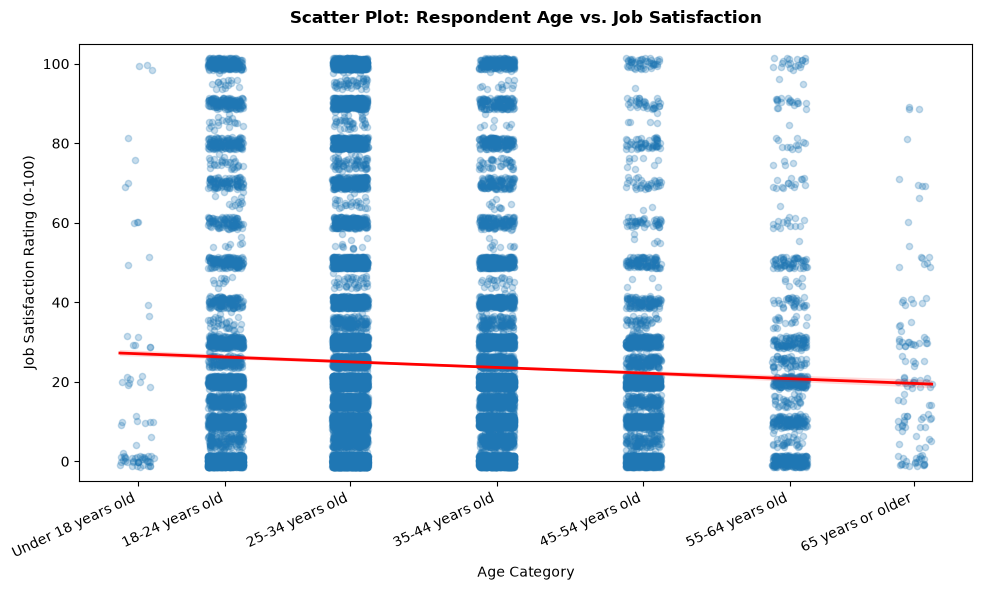

In [4]:
# Query Age and JobSatPoints_6 from df
df_age_sat = df[["Age", "JobSatPoints_6"]].dropna().copy()

# Map Age text categories to numeric midpoints
age_map = {
    "Under 18 years old": 15,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 68,
}
df_age_sat["Age_Numeric"] = df_age_sat["Age"].map(age_map)
df_age_sat = df_age_sat.dropna(subset=["Age_Numeric", "JobSatPoints_6"]).copy()

# Add random jitter to lessen visual overlap on discrete points
np.random.seed(42)
df_age_sat["Age_Jitter"] = df_age_sat["Age_Numeric"] + np.random.uniform(
    -1.2, 1.2, size=len(df_age_sat)
)
df_age_sat["Sat_Jitter"] = df_age_sat["JobSatPoints_6"] + np.random.uniform(
    -1.5, 1.5, size=len(df_age_sat)
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(
    data=df_age_sat,
    x="Age_Jitter",
    y="Sat_Jitter",
    ax=ax,
    scatter_kws={"alpha": 0.25, "s": 20, "color": "#1f77b4"},
    line_kws={"color": "red", "linewidth": 2},
)

# Set custom x-ticks matching defined age categories
tick_positions = list(age_map.values())
tick_labels = list(age_map.keys())
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=25, ha="right")

ax.set_ylim(-5, 105)

plt.title(
    "Scatter Plot: Respondent Age vs. Job Satisfaction",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Age Category", fontsize=10)
plt.ylabel("Job Satisfaction Rating (0-100)", fontsize=10)

plt.tight_layout()
plt.show()

There is no noticable connection between the age and job satisfaction

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


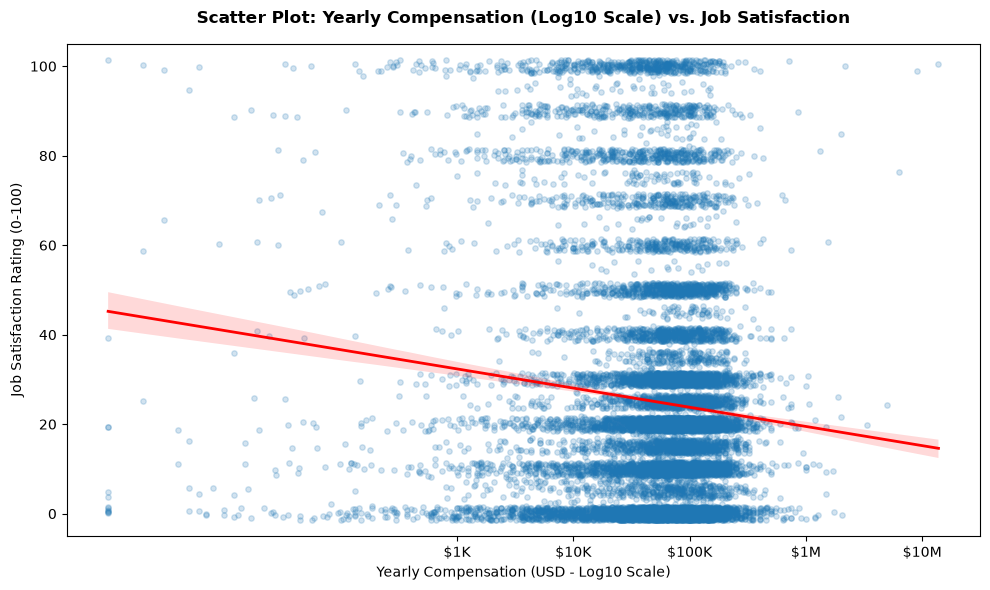

In [5]:
## Write your code here
# Select compensation and satisfaction columns from df
df_comp_sat = df[["ConvertedCompYearly", "JobSatPoints_6"]].dropna().copy()

# Filter out zero or negative compensation values
df_comp_sat = df_comp_sat[df_comp_sat["ConvertedCompYearly"] > 0].copy()

# Calculate Log10 transformed compensation
df_comp_sat["Log_Comp"] = np.log10(df_comp_sat["ConvertedCompYearly"])

# Add light jitter to satisfaction points to reduce overplotting on discrete integers
np.random.seed(42)
df_comp_sat["Sat_Jitter"] = df_comp_sat["JobSatPoints_6"] + np.random.uniform(
    -1.5, 1.5, size=len(df_comp_sat)
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(
    data=df_comp_sat,
    x="Log_Comp",
    y="Sat_Jitter",
    ax=ax,
    scatter_kws={"alpha": 0.2, "s": 15, "color": "#1f77b4"},
    line_kws={"color": "red", "linewidth": 2},
)

# Hardcode x-ticks for readable dollar compensation milestones
fixed_ticks = [3, 4, 5, 6, 7]
fixed_labels = ["$1K", "$10K", "$100K", "$1M", "$10M"]
ax.set_xticks(fixed_ticks)
ax.set_xticklabels(fixed_labels)

ax.set_ylim(-5, 105)

plt.title(
    "Scatter Plot: Yearly Compensation (Log10 Scale) vs. Job Satisfaction",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Yearly Compensation (USD - Log10 Scale)", fontsize=10)
plt.ylabel("Job Satisfaction Rating (0-100)", fontsize=10)

plt.tight_layout()
plt.show()

There could be slight corelation between comp and job satisfaction. but nothing strong.

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


In [ ]:
## Write your code here

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


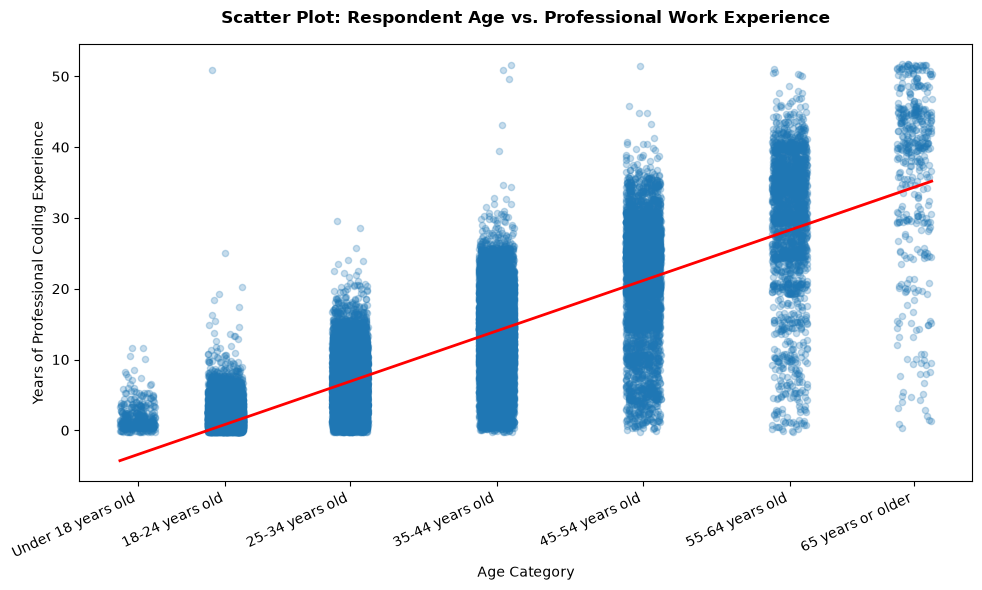

In [6]:
## Write your code here
# Select Age and YearsCodePro columns from df
df_age_exp = df[["Age", "YearsCodePro"]].dropna().copy()

# Map Age text categories to numeric midpoints
age_map = {
    "Under 18 years old": 15,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 68,
}
df_age_exp["Age_Numeric"] = df_age_exp["Age"].map(age_map)

# Clean numeric values in YearsCodePro
df_age_exp["YearsCodePro_Num"] = (
    df_age_exp["YearsCodePro"]
    .str.replace("Less than 1 year", "0.5")
    .str.replace("More than 50 years", "51")
)
df_age_exp["YearsCodePro_Num"] = pd.to_numeric(
    df_age_exp["YearsCodePro_Num"], errors="coerce"
)

# Filter valid rows
df_age_exp = df_age_exp.dropna(
    subset=["Age_Numeric", "YearsCodePro_Num"]
).copy()

# Add light jitter to age and experience points to reduce overplotting
np.random.seed(42)
df_age_exp["Age_Jitter"] = df_age_exp["Age_Numeric"] + np.random.uniform(
    -1.2, 1.2, size=len(df_age_exp)
)
df_age_exp["Exp_Jitter"] = df_age_exp["YearsCodePro_Num"] + np.random.uniform(
    -0.8, 0.8, size=len(df_age_exp)
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(
    data=df_age_exp,
    x="Age_Jitter",
    y="Exp_Jitter",
    ax=ax,
    scatter_kws={"alpha": 0.25, "s": 20, "color": "#1f77b4"},
    line_kws={"color": "red", "linewidth": 2},
)

# Set custom x-ticks matching defined age categories
tick_positions = list(age_map.values())
tick_labels = list(age_map.keys())
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=25, ha="right")

plt.title(
    "Scatter Plot: Respondent Age vs. Professional Work Experience",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Age Category", fontsize=10)
plt.ylabel("Years of Professional Coding Experience", fontsize=10)

plt.tight_layout()
plt.show()

We can see a positive corelation between the age of the respondent and the years of profetional coding experience

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


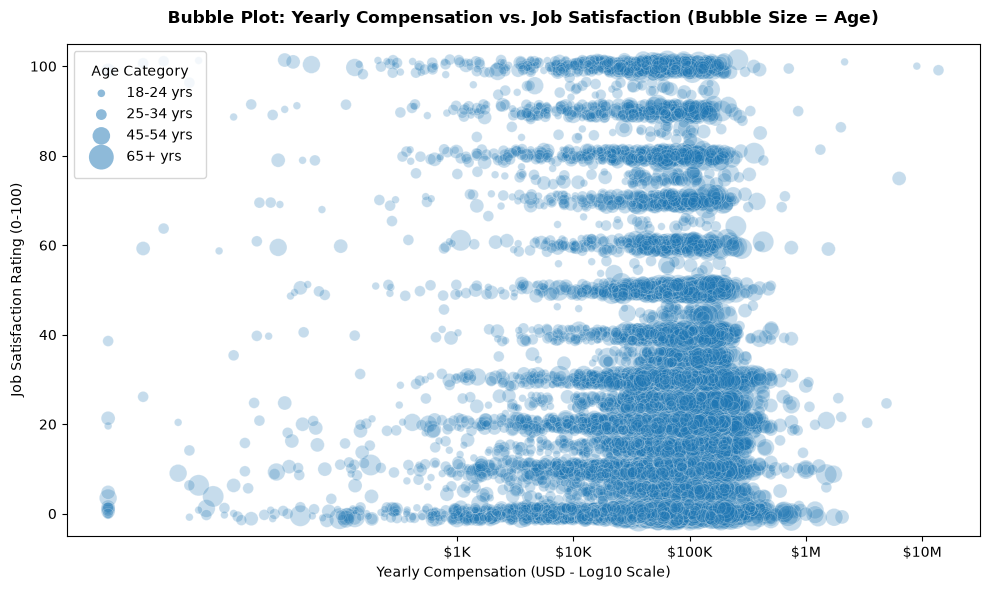

In [7]:
## Write your code here
# Select compensation, satisfaction, and age columns from df
df_bubble = df[["ConvertedCompYearly", "JobSatPoints_6", "Age"]].dropna().copy()

# Filter out zero or negative compensation values
df_bubble = df_bubble[df_bubble["ConvertedCompYearly"] > 0].copy()

# Log10 transform compensation for clear horizontal spacing
df_bubble["Log_Comp"] = np.log10(df_bubble["ConvertedCompYearly"])

# Map Age text categories to numeric midpoints to serve as bubble size
age_size_map = {
    "Under 18 years old": 15,
    "18-24 years old": 30,
    "25-34 years old": 60,
    "35-44 years old": 100,
    "45-54 years old": 160,
    "55-64 years old": 230,
    "65 years or older": 320,
}
df_bubble["Bubble_Size"] = df_bubble["Age"].map(age_size_map)
df_bubble = df_bubble.dropna(subset=["Bubble_Size"]).copy()

# Add light jitter to satisfaction values to reveal overlapping bubbles
np.random.seed(42)
df_bubble["Sat_Jitter"] = df_bubble["JobSatPoints_6"] + np.random.uniform(
    -1.5, 1.5, size=len(df_bubble)
)

fig, ax = plt.subplots(figsize=(10, 6))

# Render bubble plot
scatter = ax.scatter(
    x=df_bubble["Log_Comp"],
    y=df_bubble["Sat_Jitter"],
    s=df_bubble["Bubble_Size"],
    c="#1f77b4",
    alpha=0.25,
    edgecolors="white",
    linewidth=0.5,
)

# Format x-axis with clear currency milestones
fixed_ticks = [3, 4, 5, 6, 7]
fixed_labels = ["$1K", "$10K", "$100K", "$1M", "$10M"]
ax.set_xticks(fixed_ticks)
ax.set_xticklabels(fixed_labels)

ax.set_ylim(-5, 105)

# Build a clear legend for bubble sizes (representing age groups)
legend_sizes = [30, 60, 160, 320]
legend_labels = ["18-24 yrs", "25-34 yrs", "45-54 yrs", "65+ yrs"]
legend_handles = [
    plt.scatter([], [], s=size, c="#1f77b4", alpha=0.5, edgecolors="none")
    for size in legend_sizes
]
ax.legend(
    legend_handles,
    legend_labels,
    title="Age Category",
    loc="upper left",
    frameon=True,
    borderpad=1,
)

plt.title(
    "Bubble Plot: Yearly Compensation vs. Job Satisfaction (Bubble Size = Age)",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Yearly Compensation (USD - Log10 Scale)", fontsize=10)
plt.ylabel("Job Satisfaction Rating (0-100)", fontsize=10)

plt.tight_layout()
plt.show()

**No Clustering by Age or Pay:** Smaller bubbles (younger developers) and larger bubbles (older developers) are intermingled evenly across both low (0–20) and high (80–100) satisfaction tiers.

**Mass Concentration:** The bulk of respondents concentrate between `$20K` and `$200K`, but satisfaction scores within that core range are spread throughout the vertical axis.

**Main Analytical Takeaway:** Compensation level and age are extremely weak predictors of job satisfaction in this dataset. Work environment, role fit, and daily tasks likely exert a far stronger influence.

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


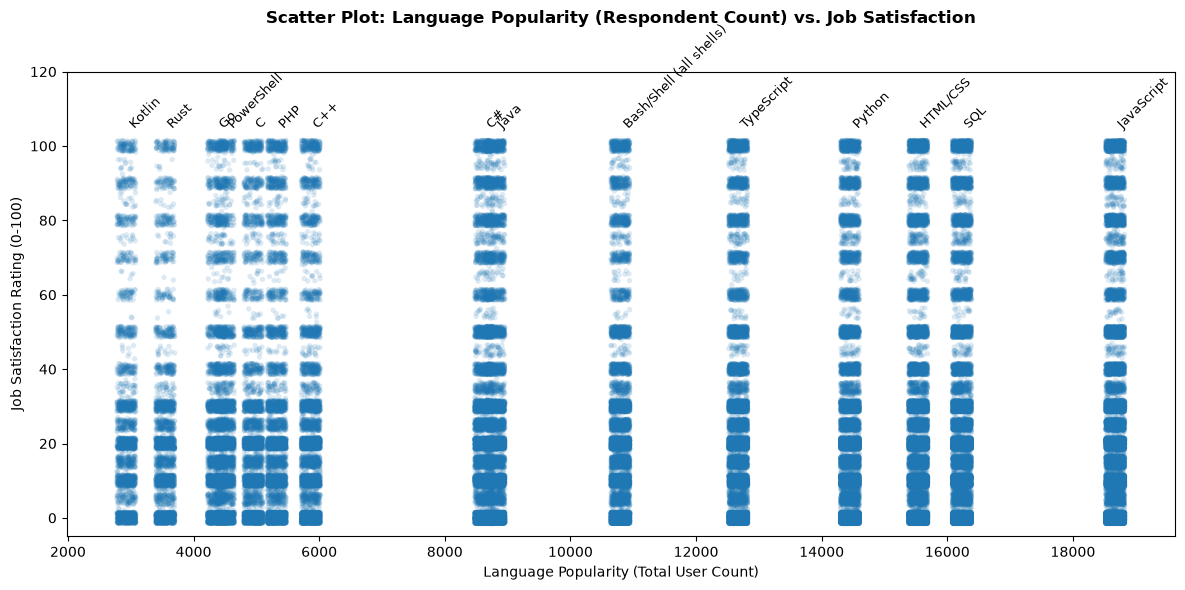

In [9]:
## Write your code here
# Query LanguageHaveWorkedWith and JobSatPoints_6 from df
df_lang_sat = df[["LanguageHaveWorkedWith", "JobSatPoints_6"]].dropna().copy()

# Split multi-selection semicolon-separated languages into individual rows
df_lang_sat["Language"] = df_lang_sat["LanguageHaveWorkedWith"].str.split(";")
df_lang_sat = df_lang_sat.explode("Language")
df_lang_sat["Language"] = df_lang_sat["Language"].str.strip()

# Calculate total response count (popularity metric) per language
lang_counts = df_lang_sat["Language"].value_counts()

# Select the top 15 most popular languages to keep the visualization clean
top_15_langs = lang_counts.head(15).index.tolist()
df_top_lang = df_lang_sat[df_lang_sat["Language"].isin(top_15_langs)].copy()

# Add frequency count column for horizontal positioning
df_top_lang["Popularity_Count"] = df_top_lang["Language"].map(lang_counts)

# Add random jitter to both axes to reveal overlapping points on discrete coordinates
np.random.seed(42)
df_top_lang["Popularity_Jitter"] = df_top_lang[
    "Popularity_Count"
] + np.random.uniform(-150, 150, size=len(df_top_lang))
df_top_lang["Sat_Jitter"] = df_top_lang["JobSatPoints_6"] + np.random.uniform(
    -1.5, 1.5, size=len(df_top_lang)
)

fig, ax = plt.subplots(figsize=(12, 6))

# Scatter plot showing respondent density per language popularity vs satisfaction rating
ax.scatter(
    x=df_top_lang["Popularity_Jitter"],
    y=df_top_lang["Sat_Jitter"],
    alpha=0.15,
    s=15,
    c="#1f77b4",
    edgecolors="none",
)

# Label top languages at their total count coordinates along the top of the plot
unique_top = (
    df_top_lang[["Language", "Popularity_Count"]]
    .drop_duplicates()
    .sort_values("Popularity_Count", ascending=False)
)
for _, row in unique_top.iterrows():
    ax.text(
        x=row["Popularity_Count"],
        y=104,
        s=row["Language"],
        rotation=45,
        ha="left",
        va="bottom",
        fontsize=9,
    )

ax.set_ylim(-5, 120)

plt.title(
    "Scatter Plot: Language Popularity (Respondent Count) vs. Job Satisfaction",
    fontsize=12,
    fontweight="bold",
    pad=35,
)
plt.xlabel("Language Popularity (Total User Count)", fontsize=10)
plt.ylabel("Job Satisfaction Rating (0-100)", fontsize=10)

plt.tight_layout()
plt.show()

**Uniform Vertical Columns:** Every single language column forms a complete vertical block spanning from 0 to 100 satisfaction rating.

**Stack Independence:** Developers using niche technologies (like Kotlin or Rust) report the exact same full distribution of satisfaction levels as developers using massive ecosystems (like JavaScript, SQL, or Python).

**Summary Insight:** Language adoption rate is completely orthogonal to how satisfied developers are in their daily roles.

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


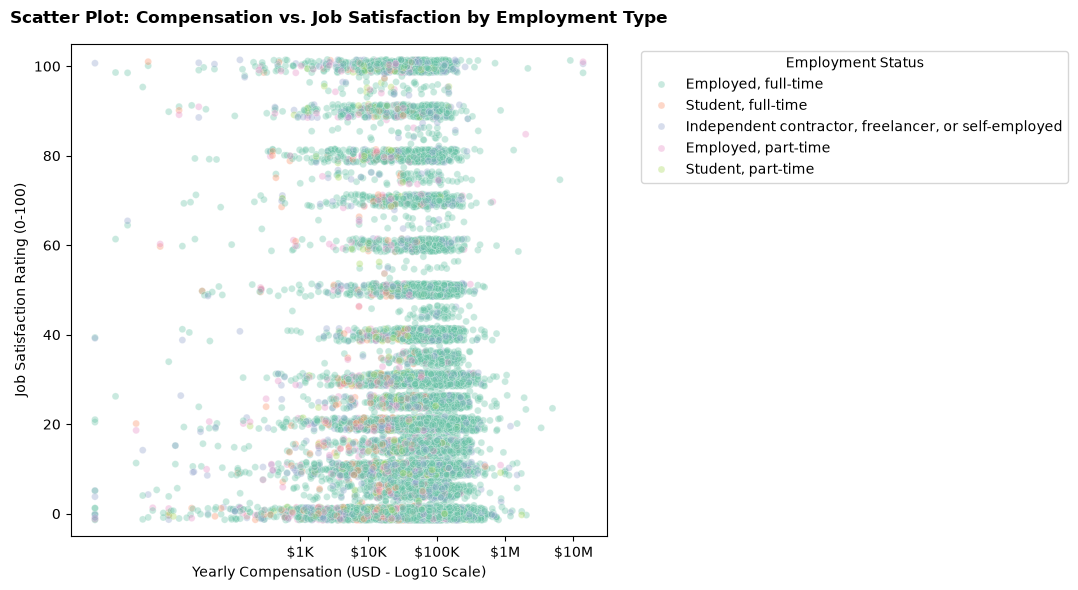

In [11]:
# Query ConvertedCompYearly, JobSatPoints_6, and Employment from df
df_emp_sat = df[["ConvertedCompYearly", "JobSatPoints_6", "Employment"]].dropna().copy()

# Filter out non-positive compensation values
df_emp_sat = df_emp_sat[df_emp_sat["ConvertedCompYearly"] > 0].copy()

# Log10 transform compensation for readable spacing
df_emp_sat["Log_Comp"] = np.log10(df_emp_sat["ConvertedCompYearly"])

# Explode multi-selection semicolon-separated Employment categories
df_emp_sat["Employment_Split"] = df_emp_sat["Employment"].str.split(";")
df_emp_sat = df_emp_sat.explode("Employment_Split")
df_emp_sat["Employment_Split"] = df_emp_sat["Employment_Split"].str.strip()

# Select top employment categories to avoid legend clutter
top_employments = df_emp_sat["Employment_Split"].value_counts().head(5).index.tolist()
df_emp_filtered = df_emp_sat[df_emp_sat["Employment_Split"].isin(top_employments)].copy()

# Add random jitter to satisfaction to handle discrete points
np.random.seed(42)
df_emp_filtered["Sat_Jitter"] = df_emp_filtered["JobSatPoints_6"] + np.random.uniform(
    -1.5, 1.5, size=len(df_emp_filtered)
)

fig, ax = plt.subplots(figsize=(11, 6))

# Render categorical scatter plot color-coded by Employment type
sns.scatterplot(
    data=df_emp_filtered,
    x="Log_Comp",
    y="Sat_Jitter",
    hue="Employment_Split",
    alpha=0.35,
    s=25,
    palette="Set2",
    legend=True,
    ax=ax,
)

# Format x-ticks with clear dollar milestones
fixed_ticks = [3, 4, 5, 6, 7]
fixed_labels = ["$1K", "$10K", "$100K", "$1M", "$10M"]
ax.set_xticks(fixed_ticks)
ax.set_xticklabels(fixed_labels)

ax.set_ylim(-5, 105)

plt.title(
    "Scatter Plot: Compensation vs. Job Satisfaction by Employment Type",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Yearly Compensation (USD - Log10 Scale)", fontsize=10)
plt.ylabel("Job Satisfaction Rating (0-100)", fontsize=10)
plt.legend(title="Employment Status", bbox_to_anchor=(1.05, 1), loc="upper left", frameon=True)

plt.tight_layout()
plt.show()

We can see that all types of emplyment are present across all satisfaction rating

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


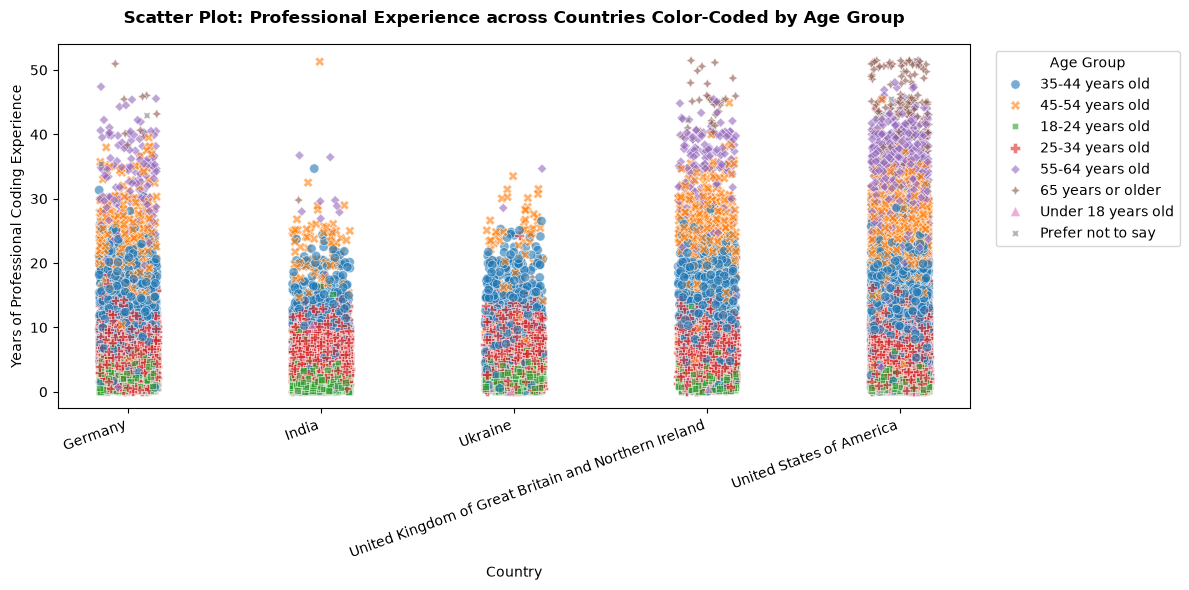

In [17]:
df_filtered = df[["YearsCodePro", "Age", "Country"]].dropna().copy()

df_filtered["YearsCodePro_Num"] = (
    df_filtered["YearsCodePro"]
    .str.replace("Less than 1 year", "0.5")
    .str.replace("More than 50 years", "51")
)
df_filtered["YearsCodePro_Num"] = pd.to_numeric(
    df_filtered["YearsCodePro_Num"], errors="coerce"
)

top_countries = (
    df_filtered["Country"].value_counts().head(5).index.tolist()
)
df_filtered = df_filtered[
    (df_filtered["Country"].isin(top_countries))
    & (df_filtered["YearsCodePro_Num"].notna())
].copy()

np.random.seed(42)
country_codes = pd.Categorical(df_filtered["Country"]).codes
df_filtered["Country_Jitter"] = country_codes + np.random.uniform(
    -0.15, 0.15, size=len(df_filtered)
)
df_filtered["Exp_Jitter"] = df_filtered[
    "YearsCodePro_Num"
] + np.random.uniform(-0.5, 0.5, size=len(df_filtered))

fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df_filtered,
    x="Country_Jitter",
    y="Exp_Jitter",
    hue="Age",
    style="Age",
    alpha=0.6,
    s=45,
    ax=ax,
)

ax.set_xticks(range(len(top_countries)))
ax.set_xticklabels(
    pd.Categorical(df_filtered["Country"]).categories,
    rotation=20,
    ha="right",
)

plt.title(
    "Scatter Plot: Professional Experience across Countries Color-Coded by Age Group",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Country", fontsize=10)
plt.ylabel("Years of Professional Coding Experience", fontsize=10)
plt.legend(title="Age Group", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

plt.tight_layout()
plt.show()

Strong Layered Age Demographics: Age brackets form clear horizontal stratification bands (green 18–24 at the bottom, red 25–34 above it, blue 35–44 in the middle, up to purple 55–64 near the top). Work experience maps directly to physical age across all regions.

Younger Workforce Skew in Emerging Markets: India and Ukraine show significantly lower overall point density above 30 years of professional experience compared to the US and UK, reflecting younger developer demographics in those tech hubs.

Seniority Ceiling in Western Markets: The US, UK, and Germany feature substantial representations of senior talent (30–50+ years of experience), whereas India and Ukraine cap out heavily around the 25–30 year mark.

Uniform Core Density: Across all five countries, the highest concentration of respondents (thickest visual band) consistently clusters between 2 and 15 years of experience (the 18–24 and 25–34 age brackets).

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
